# Avance 1 - Análisis Exploratorio de Datos (EDA)

## Proyecto Integrador
### ThreatLLM: Clasificación de Ciberataques mediante Modelos de Lenguaje

**Equipo 55**

**Integrantes**
- Ada Jimena Vargas Aguirre — A01701619
- Edson Garduño Nolasco — A01795770
- Irving Alan García Zapata — A01796793

**Materia:** Proyecto Integrador  
**Actividad:** Avance 1 - Análisis Exploratorio de Datos (EDA)  
**Asesor:** Dr. Víctor Munguía

---

## Objetivo

Realizar un análisis exploratorio de los datasets del framework LADDER para comprender su estructura, calidad y principales características, identificando posibles problemas de los datos y definiendo las estrategias de preprocesamiento que serán utilizadas en las siguientes etapas del proyecto ThreatLLM.

---

## Dataset analizado

El proyecto utiliza los datasets del framework **LADDER (Looking Beyond IoCs: Automatically Extracting Attack Patterns from External CTI)**, los cuales representan distintas etapas de un pipeline de análisis de amenazas:

| Dataset | Propósito |
|----------|----------|
| sentence_classification | Identificar si una oración describe una acción de ataque |
| entity_extraction | Identificar el fragmento exacto que contiene la acción maliciosa |
| attack-pattern-matching-gt | Asociar una descripción textual con una técnica MITRE ATT&CK |

---

## Flujo general del proyecto

```text
Reporte CTI
     ↓
sentence_classification
     ↓
entity_extraction
     ↓
attack-pattern-matching-gt
     ↓
Técnica MITRE ATT&CK
     ↓
Apoyo al analista SOC

# 1. Carga y descripción de los datasets

El framework LADDER proporciona tres datasets complementarios que representan distintas etapas del proceso de identificación y clasificación de amenazas cibernéticas.

| Dataset | Propósito |
|----------|----------|
| sentence_classification | Determinar si una oración describe una acción de ataque |
| entity_extraction | Identificar el fragmento de texto que contiene la acción maliciosa |
| attack-pattern-matching-gt | Asociar una descripción textual con una técnica MITRE ATT&CK |

Estos datasets forman parte de un pipeline secuencial que transforma información no estructurada proveniente de reportes de inteligencia de amenazas en conocimiento clasificado según el marco MITRE ATT&CK.

```text
Reporte CTI
     ↓
sentence_classification
     ↓
entity_extraction
     ↓
attack-pattern-matching-gt
     ↓
Técnica MITRE ATT&CK
```

A continuación se cargan los datasets y se valida que la información se encuentre disponible para el análisis exploratorio.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

import re
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid",
    palette="muted"
)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [ ]:
def load_sentence_classification(path):
    df = pd.read_csv(path, sep="\t")
    df["word_count"] = df["text"].str.split().str.len()
    return df

def load_entity_extraction(path):
    rows = []
    sentence_id = 0

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                sentence_id += 1
                continue

            token, label = line.rsplit(" ", 1)

            rows.append({
                "token": token,
                "label": label,
                "sentence_id": sentence_id
            })

    return pd.DataFrame(rows)

In [ ]:
from pathlib import Path

BASE = Path("/content")

SC_DIR = BASE / "sentence_classification"
EE_DIR = BASE / "entity_extraction"
AP_FILE = BASE / "attack-pattern-matching-gt.csv"

print("Rutas configuradas correctamente")
print(SC_DIR)
print(EE_DIR)
print(AP_FILE)

# Carga de datos
sc_train = load_sentence_classification(SC_DIR / "train.csv")
sc_dev   = load_sentence_classification(SC_DIR / "dev.csv")
sc_test  = load_sentence_classification(SC_DIR / "test.csv")

ee_train = load_entity_extraction(EE_DIR / "train.txt")
ee_dev   = load_entity_extraction(EE_DIR / "dev.txt")
ee_test  = load_entity_extraction(EE_DIR / "test.txt")

ap = pd.read_csv(AP_FILE)
ap["word_count"] = ap["text"].str.split().str.len()

Rutas configuradas correctamente
/content/sentence_classification
/content/entity_extraction
/content/attack-pattern-matching-gt.csv


In [4]:
summary = pd.DataFrame({
    "Dataset": [
        "sentence_classification (train)",
        "sentence_classification (dev)",
        "sentence_classification (test)",
        "entity_extraction (train)",
        "entity_extraction (dev)",
        "entity_extraction (test)",
        "attack-pattern-matching-gt"
    ],
    "Registros": [
        len(sc_train),
        len(sc_dev),
        len(sc_test),
        len(ee_train),
        len(ee_dev),
        len(ee_test),
        len(ap)
    ]
})

display(summary)

,Dataset,Registros
0,sentence_classification (train),2214
1,sentence_classification (dev),568
2,sentence_classification (test),662
3,entity_extraction (train),25443
4,entity_extraction (dev),7101
5,entity_extraction (test),6490
6,attack-pattern-matching-gt,81


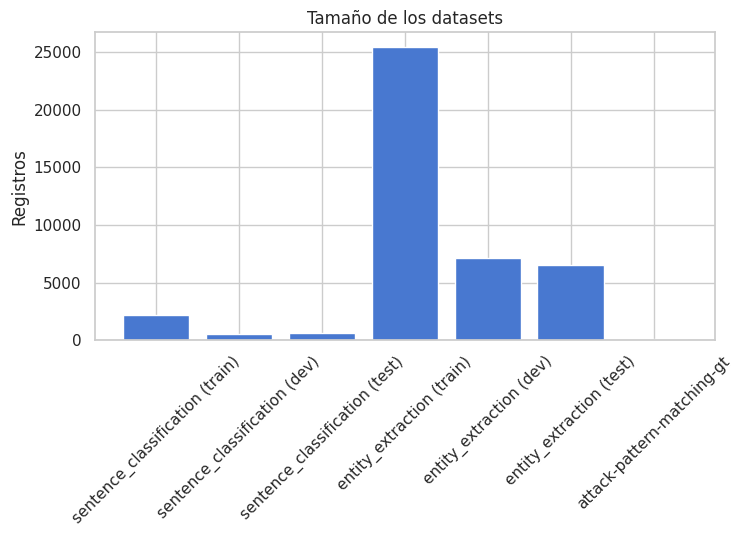

In [5]:
plt.figure(figsize=(8,4))

plt.bar(
    summary["Dataset"],
    summary["Registros"]
)

plt.xticks(rotation=45)
plt.ylabel("Registros")
plt.title("Tamaño de los datasets")

plt.show()

### Observaciones

- El framework LADDER está compuesto por tres datasets que representan distintas etapas del pipeline de análisis de amenazas.
- Los datasets `sentence_classification` y `entity_extraction` contienen la mayor parte de la información disponible para entrenamiento y análisis.
- El dataset `attack-pattern-matching-gt` contiene únicamente 81 registros, por lo que representa el conjunto más pequeño y requerirá especial atención durante las etapas de entrenamiento y evaluación.
- La estructura de los datos es consistente con tareas de Procesamiento de Lenguaje Natural orientadas a clasificación de texto y reconocimiento de entidades.
- Los tres datasets se complementan entre sí y permiten recorrer el proceso completo desde una descripción textual hasta la identificación de una técnica MITRE ATT&CK.

# 2. Calidad de los datos

Antes de analizar la distribución y comportamiento de los datos, es necesario evaluar su calidad para identificar posibles problemas que puedan afectar el desempeño de los modelos.

En esta sección se revisan:

- Valores faltantes.
- Registros duplicados.
- Textos vacíos.
- Consistencia de variables categóricas.

Estos análisis permitirán determinar si es necesario aplicar estrategias de limpieza antes de las etapas de modelado.

In [6]:
datasets = {
    "sentence_classification": pd.concat([
        sc_train,
        sc_dev,
        sc_test
    ]),
    "entity_extraction": pd.concat([
        ee_train,
        ee_dev,
        ee_test
    ]),
    "attack-pattern-matching-gt": ap
}

## Valores faltantes

La presencia de valores faltantes puede afectar el entrenamiento y evaluación de los modelos. Por ello, se verifica la cantidad de datos ausentes en cada dataset.

In [ ]:
missing_summary = []

for name, df in datasets.items():
    missing_summary.append({
        "Dataset": name,
        "Valores faltantes": df.isnull().sum().sum()
    })

missing_summary = pd.DataFrame(
    missing_summary
)

display(missing_summary)

,Dataset,Valores faltantes
0,sentence_classification,0
1,entity_extraction,0
2,attack-pattern-matching-gt,0


## Registros duplicados

Se evalúa la existencia de registros duplicados que puedan introducir sesgos durante el entrenamiento.

In [ ]:
duplicate_summary = pd.DataFrame({
    "Dataset": [
        "sentence_classification",
        "entity_extraction",
        "attack-pattern-matching-gt"
    ],
    "Duplicados": [
        pd.concat([
            sc_train,
            sc_dev,
            sc_test
        ]).duplicated().sum(),

        pd.concat([
            ee_train,
            ee_dev,
            ee_test
        ]).duplicated().sum(),

        ap.duplicated().sum()
    ]
})

display(duplicate_summary)

,Dataset,Duplicados
0,sentence_classification,0
1,entity_extraction,4543
2,attack-pattern-matching-gt,0


## Variables categóricas

Se valida la cantidad de categorías únicas presentes en las variables más importantes del dataset de clasificación de técnicas ATT&CK.

In [ ]:
category_summary = pd.DataFrame({
    "Variable": [
        "malware",
        "label"
    ],
    "Categorías únicas": [
        ap["malware"].nunique(),
        ap["label"].nunique()
    ]
})

display(category_summary)

,Variable,Categorías únicas
0,malware,19
1,label,31


## Hallazgos de calidad de datos

- No se identificaron valores faltantes en ninguno de los datasets analizados.
- No se encontraron textos vacíos en los conjuntos de datos utilizados.
- Los datasets `sentence_classification` y `attack-pattern-matching-gt` no presentan registros duplicados.
- Se identificaron registros repetidos en `entity_extraction`; sin embargo, corresponden a ocurrencias válidas de tokens y no representan errores de calidad.
- Se detectaron 19 familias de malware y 31 técnicas MITRE ATT&CK, lo que confirma la diversidad de categorías presentes en el corpus.

En general, los datos presentan un nivel adecuado de calidad y consistencia para continuar con las etapas de análisis y modelado sin requerir procesos complejos de limpieza.

# 3. Análisis univariante

El análisis univariante permite estudiar cada variable de forma individual para comprender su distribución y comportamiento dentro del corpus.

Debido a que ThreatLLM es un proyecto de Procesamiento de Lenguaje Natural, el análisis se centra principalmente en la longitud de los textos, la distribución de las clases y la frecuencia de las categorías más importantes.

## Longitud de los textos

Se analizan las estadísticas descriptivas de la variable `word_count`, la cual representa el número de palabras contenidas en cada oración.

In [10]:
sc_all = pd.concat([
    sc_train.assign(split="train"),
    sc_dev.assign(split="dev"),
    sc_test.assign(split="test")
])

display(
    sc_all.groupby("split")["word_count"]
    .describe()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,568.0,18.83,10.49,1.0,11.0,18.0,25.00,67.0
test,662.0,16.66,11.82,1.0,7.0,15.0,24.00,84.0
train,2214.0,18.33,11.37,1.0,9.0,18.0,25.75,98.0


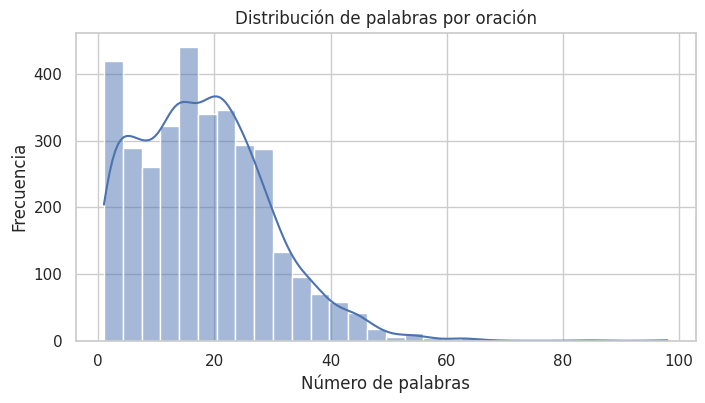

In [11]:
plt.figure(figsize=(8,4))

sns.histplot(
    sc_all["word_count"],
    bins=30,
    kde=True,
    color="#4c72b0"
)

plt.title("Distribución de palabras por oración")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")

plt.show()

## Balance de clases

Se analiza la distribución de la variable objetivo del dataset `sentence_classification`.

,count
label,
0,1722
1,1722


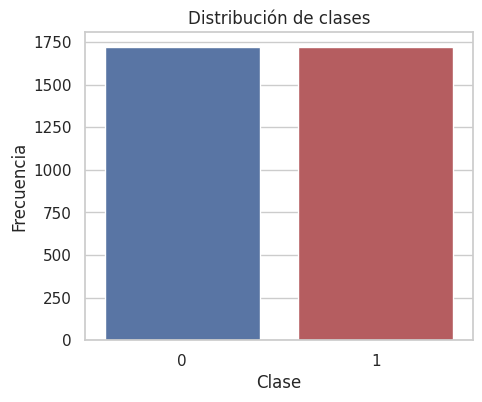

In [12]:
class_distribution = (
    pd.concat([
        sc_train,
        sc_dev,
        sc_test
    ])["label"]
    .value_counts()
    .sort_index()
)

display(class_distribution)

plt.figure(figsize=(5,4))

sns.barplot(
    x=class_distribution.index.astype(str),
    y=class_distribution.values,
    palette=["#4c72b0", "#c44e52"]
)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")

plt.show()

## Técnicas MITRE ATT&CK

Se analiza la frecuencia de las técnicas ATT&CK presentes en el dataset `attack-pattern-matching-gt`.

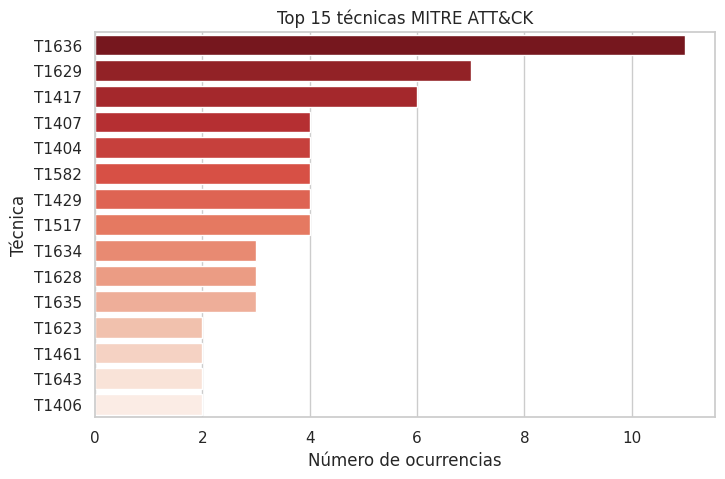

In [13]:
technique_count = (
    ap["label"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=technique_count.values,
    y=technique_count.index,
    palette="Reds_r"
)

plt.title("Top 15 técnicas MITRE ATT&CK")
plt.xlabel("Número de ocurrencias")
plt.ylabel("Técnica")

plt.show()

## Hallazgos

- La longitud promedio de los textos se encuentra entre 16 y 19 palabras por oración.
- La mayoría de las observaciones contiene menos de 30 palabras, aunque existen algunos casos más extensos.
- El dataset `sentence_classification` presenta un balance prácticamente perfecto entre las clases de ataque y no ataque.
- El dataset `attack-pattern-matching-gt` contiene 31 técnicas diferentes del marco MITRE ATT&CK.
- Las técnicas más frecuentes son `T1636`, `T1629` y `T1417`.
- Se observa un desbalance en la frecuencia de las técnicas ATT&CK, ya que algunas categorías tienen más ejemplos que otras.

En general, el corpus presenta características adecuadas para tareas de clasificación de texto y análisis semántico.
`

# 4. Análisis bivariante

El análisis bivariante permite explorar relaciones entre variables y detectar patrones que puedan ser relevantes para el entrenamiento de los modelos.

Para este proyecto se analizarán dos relaciones importantes:

- Longitud del texto y clase objetivo.
- Diversidad de técnicas ATT&CK por familia de malware.

## Longitud del texto según la clase

Se analiza si existe alguna diferencia entre la longitud de las oraciones de ataque y las de contexto.

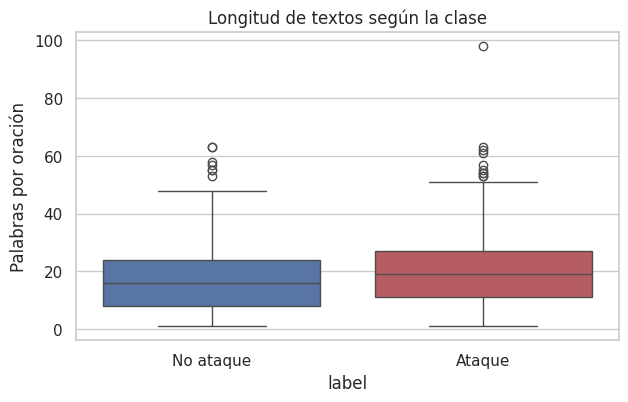

In [14]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=sc_train,
    x="label",
    y="word_count",
    palette={
        "0": "#4c72b0",
        "1": "#c44e52"
    }
)

plt.xticks(
    [0,1],
    ["No ataque", "Ataque"]
)

plt.title("Longitud de textos según la clase")
plt.ylabel("Palabras por oración")

plt.show()

In [15]:
group_stats = (
    sc_train
    .groupby("label")["word_count"]
    .agg(["mean", "median"])
    .round(2)
)

display(group_stats)

,mean,median
label,,
0,16.85,16.0
1,19.81,19.0


## Diversidad de técnicas ATT&CK por malware

Se analiza cuántas técnicas ATT&CK diferentes aparecen asociadas a cada familia de malware.

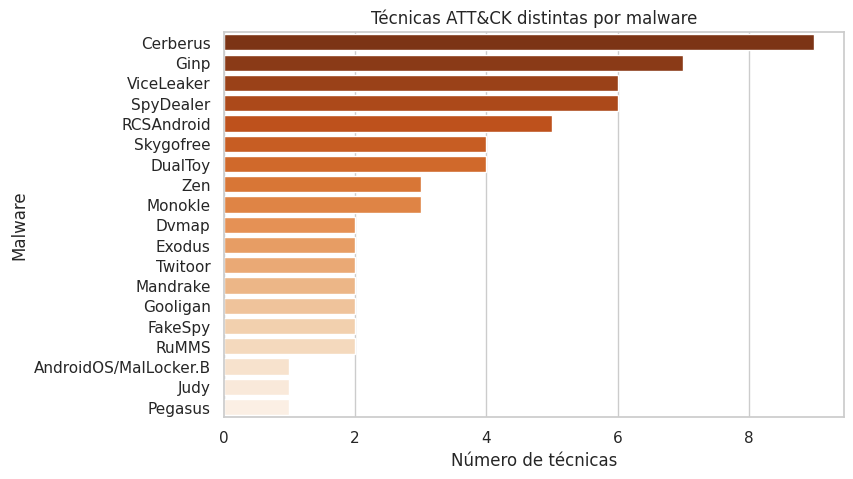

In [16]:
malware_techniques = (
    ap.groupby("malware")["label"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=malware_techniques.values,
    y=malware_techniques.index,
    palette="Oranges_r"
)

plt.title("Técnicas ATT&CK distintas por malware")
plt.xlabel("Número de técnicas")
plt.ylabel("Malware")

plt.show()

## Hallazgos

- Las oraciones de ataque presentan una longitud promedio de 19.81 palabras, mientras que las oraciones de contexto tienen una longitud promedio de 16.85 palabras.
- Las descripciones de ataque son aproximadamente un 17.6% más largas que las oraciones que no describen actividades maliciosas.
- Cerberus es la familia de malware con mayor diversidad táctica, al estar asociada con 9 técnicas ATT&CK diferentes.
- Ginp, ViceLeaker y SpyDealer también presentan múltiples técnicas asociadas.
- Una misma familia de malware puede relacionarse con varias técnicas ATT&CK, por lo que la clasificación dependerá principalmente del contenido del texto y no únicamente de la familia de malware.

Estos resultados respaldan el uso de técnicas de NLP capaces de comprender el significado y contexto de las descripciones analizadas.

# 5. Preprocesamiento propuesto

Con base en los hallazgos obtenidos durante el análisis exploratorio, se definieron las estrategias de preparación de datos que serán utilizadas en las siguientes etapas del proyecto.

El objetivo es conservar la información relevante del corpus y preparar los datos para modelos de clasificación basados en NLP, embeddings y arquitecturas Transformer.

## Decisiones de preprocesamiento

In [ ]:
preprocessing_summary = pd.DataFrame({
    "Aspecto": [
        "Valores faltantes",
        "Duplicados",
        "Outliers",
        "Cardinalidad",
        "Normalización",
        "Representación semántica"
    ],
    "Decisión": [
        "No requiere tratamiento",
        "Conservar registros",
        "No eliminar",
        "Mantener categorías",
        "Limpieza básica",
        "Embeddings y Transformers"
    ]
})

display(preprocessing_summary)

,Aspecto,Decisión
0,Valores faltantes,No requiere tratamiento
1,Duplicados,Conservar registros
2,Outliers,No eliminar
3,Cardinalidad,Mantener categorías
4,Normalización,Limpieza básica
5,Representación semántica,Embeddings y Transformers


## Normalización del texto

Como preparación para las siguientes etapas se propone aplicar:

- Conversión a minúsculas.
- Eliminación de espacios redundantes.
- Tokenización.
- Preparación para generación de embeddings.

In [18]:
sample_text = ap["text"].iloc[3]

normalized_text = (
    sample_text
    .lower()
    .strip()
)

print("Texto original:")
print(sample_text)

print("\nTexto normalizado:")
print(normalized_text)

Texto original:
abusing Accessibility Service to become the default SMS app

Texto normalizado:
abusing accessibility service to become the default sms app


In [19]:
Q1 = sc_all["word_count"].quantile(0.25)
Q3 = sc_all["word_count"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (
    (sc_all["word_count"] < lower) |
    (sc_all["word_count"] > upper)
).sum()

print(f"Outliers detectados: {outliers}")

Outliers detectados: 29


## Hallazgos

- No se identificaron valores faltantes ni textos vacíos en los datasets analizados.
- Los registros duplicados detectados en `entity_extraction` corresponden a ocurrencias válidas de tokens y no serán eliminados.
- La cardinalidad observada (19 familias de malware y 31 técnicas ATT&CK) es adecuada para tareas de clasificación y no requiere agrupación de categorías.
- Se identificaron 29 observaciones atípicas; sin embargo, corresponden a descripciones legítimas de actividades maliciosas y serán conservadas durante el modelado.- Se aplicará una normalización básica del texto como preparación para las fases de entrenamiento.
- Debido a la diversidad del vocabulario y la naturaleza semántica del problema, se evaluarán representaciones basadas en embeddings y modelos Transformer.

Estas decisiones servirán como base para la etapa de preparación de datos y construcción de modelos dentro del proyecto ThreatLLM.

## Consideraciones para modelado

Con el objetivo de estimar un tamaño adecuado de secuencia para modelos basados en Transformers, se evaluó la cobertura del corpus usando diferentes configuraciones de `max_length`.

In [ ]:
max_lengths = [32, 64, 128]

for max_len in max_lengths:
    coverage = (
        (sc_all["word_count"] <= max_len)
        .mean()
        * 100
    )

    print(
        f"max_length={max_len}: "
        f"{coverage:.2f}%"
    )

max_length=32: 89.90%
max_length=64: 99.91%
max_length=128: 100.00%


### Observaciones

- El 90% del corpus contiene aproximadamente 33 palabras o menos.
- Una configuración de `max_length = 64` cubre el 99.91% de las observaciones.
- Un valor de `max_length = 128` cubre la totalidad del corpus.

Estos resultados indican que el corpus puede ser procesado eficientemente mediante modelos Transformer sin requerir ventanas de contexto excesivamente grandes.

# 5. Conclusiones

El análisis exploratorio permitió comprender las características principales de los datasets que conforman el framework LADDER y obtener información relevante para las siguientes etapas del proyecto ThreatLLM.

Los principales hallazgos fueron los siguientes:

- No se identificaron valores faltantes ni textos vacíos en los datasets analizados.
- Los registros duplicados detectados en `entity_extraction` corresponden a ocurrencias válidas de tokens y no representan problemas de calidad.
- El dataset `sentence_classification` presenta un balance prácticamente perfecto entre las clases de ataque y no ataque.
- El dataset `attack-pattern-matching-gt` contiene 19 familias de malware y 31 técnicas diferentes del marco MITRE ATT&CK.
- Las técnicas más frecuentes corresponden a `T1636`, `T1629` y `T1417`, observándose un desbalance moderado entre categorías.
- La longitud promedio de los textos se encuentra entre 16 y 19 palabras por oración.
- El 90% del corpus contiene 33 palabras o menos, mientras que el 99% contiene aproximadamente 49 palabras o menos.
- Una configuración de `max_length = 64` permitiría cubrir el 99.91% de las observaciones disponibles.
- La familia Cerberus presenta la mayor diversidad táctica dentro del conjunto analizado, al estar asociada con 9 técnicas ATT&CK distintas.
- El vocabulario observado es amplio y especializado, con más de 4,000 términos únicos relacionados con el dominio de la ciberseguridad.

Con base en estos resultados, se considera que el corpus posee la calidad y estructura necesarias para continuar con las siguientes fases del proyecto. Como preparación para la etapa de modelado, se aplicará una normalización básica del texto y se evaluarán representaciones semánticas mediante embeddings y arquitecturas Transformer para la clasificación de técnicas ATT&CK.